## Packages & Data

In [1]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt

In [2]:
# Load data
df = pl.scan_csv("../auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
df.show(5)

time,src_user,dest_user,src_comp,dest_comp,auth_type,logon_type,auth_orientation,outcome
i64,str,str,str,str,str,str,str,str
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
1,"""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
1,"""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
1,"""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


## Auth counts

In [3]:
# Event Count
df.select(pl.len()).collect().item()

1051430459

In [7]:
# Human user counts
src_users = (
    df
    .filter(pl.col("src_user").str.starts_with("U"))
    .select(pl.col("src_user").unique())
    .collect()
    .to_series()
)

dest_users = (
    df
    .filter(pl.col("dest_user").str.starts_with("U"))
    .select(pl.col("dest_user").unique())
    .collect()
    .to_series()
)

all_users = set(src_users.to_list()) | set(dest_users.to_list())

print(f"Distinct src human users:  {src_users.n_unique():,}")
print(f"Distinct dest human users: {dest_users.n_unique():,}")
print(f"Union (src ∪ dest):        {len(all_users):,}")

Distinct src human users:  30,342
Distinct dest human users: 30,801
Union (src ∪ dest):        32,116


In [6]:
# Machine Counts
src_machines = (
    df
    .filter(pl.col("src_user").str.contains(r"\$"))
    .select(pl.col("src_user").unique())
    .collect()
    .to_series()
)

dest_machines = (
    df
    .filter(pl.col("dest_user").str.contains(r"\$"))
    .select(pl.col("dest_user").unique())
    .collect()
    .to_series()
)

all_machines = set(src_machines.to_list()) | set(dest_machines.to_list())

print(f"Distinct src machine accounts:  {src_machines.n_unique():,}")
print(f"Distinct dest machine accounts: {dest_machines.n_unique():,}")
print(f"Union (src ∪ dest):             {len(all_machines):,}")

Distinct src machine accounts:  17,586
Distinct dest machine accounts: 17,517
Union (src ∪ dest):             17,606


In [ ]:
# Computer Counts
src_set = (
    df.select(pl.col("src_comp").unique())
      .collect()
      .to_series()
)

dest_set = (
    df.select(pl.col("dest_comp").unique())
      .collect()
      .to_series()
)

all_computers = set(src_set.to_list()) | set(dest_set.to_list())

print(f"Distinct source computers:      {src_set.n_unique():,}")
print(f"Distinct destination computers: {dest_set.n_unique():,}")
print(f"Distinct computers (union):     {len(all_computers):,}")

Distinct source computers:      16,230
Distinct destination computers: 15,895
Distinct computers (union):     17,666


In [ ]:
# Proportion of events for machine/user/other
event_proportions = (
    df
    .select(
        total=pl.len(),
        machine_events=pl.col("src_user").str.contains(r"\$").sum(),
        user_events=pl.col("src_user").str.starts_with("U").sum(),
    )
    .with_columns(
        other_events=pl.col("total") - pl.col("machine_events") - pl.col("user_events"),
    )
    .with_columns(
        machine_pct=(pl.col("machine_events") / pl.col("total") * 100).round(2),
        user_pct=(pl.col("user_events") / pl.col("total") * 100).round(2),
        other_pct=(pl.col("other_events") / pl.col("total") * 100).round(2),
    )
    .collect()
)

event_proportions

total,machine_events,user_events,other_events,machine_pct,user_pct,other_pct
u32,u32,u32,u32,f64,f64,f64
1051430459,633193503,341692445,76544511,60.22,32.5,7.28


In [7]:
user_failure = (
    df
    .filter(pl.col("src_user").str.starts_with("U"))
    .with_columns(is_fail=(pl.col("outcome") == "Fail").cast(pl.Int64))
    .group_by("src_user")
    .agg(
        n_auths=pl.len(),
        n_fails=pl.col("is_fail").sum(),
    )
    .with_columns(failure_rate=pl.col("n_fails") / pl.col("n_auths"))
    .collect(streaming=True)     
)

user_failure.describe()

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_14801/1434987998.py:11: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)      # <-- processes in chunks, bounded memory


statistic,src_user,n_auths,n_fails,failure_rate
str,str,f64,f64,f64
"""count""","""30342""",30342.0,30342.0,30342.0
"""null_count""","""0""",0.0,0.0,0.0
"""mean""",null,11261.368565,324.024224,0.400958
"""std""",null,131461.440087,7400.852631,0.481838
"""min""","""U10000@?""",1.0,0.0,0.0
"""25%""",null,16.0,0.0,0.0
"""50%""",null,106.0,3.0,0.00113
"""75%""",null,7651.0,35.0,1.0
"""max""","""U9@win.lanl.gov""",1.6595241e7,572358.0,1.0


In [8]:
machine_failure = (
    df
    .filter(pl.col("src_user").str.contains(r"\$"))      
    .with_columns(is_fail=(pl.col("outcome") == "Fail").cast(pl.Int64))
    .group_by("src_user")
    .agg(
        n_auths=pl.len(),
        n_fails=pl.col("is_fail").sum(),
    )
    .with_columns(failure_rate=pl.col("n_fails") / pl.col("n_auths"))
    .collect(streaming=True)
)

machine_failure.describe()

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_14801/525695574.py:11: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


statistic,src_user,n_auths,n_fails,failure_rate
str,str,f64,f64,f64
"""count""","""17586""",17586.0,17586.0,17586.0
"""null_count""","""0""",0.0,0.0,0.0
"""mean""",null,36005.544353,170.558512,0.210908
"""std""",null,169470.162661,3608.785884,0.405809
"""min""","""C1$@DOM1""",1.0,0.0,0.0
"""25%""",null,794.0,0.0,0.0
"""50%""",null,25304.0,3.0,0.000328
"""75%""",null,43404.0,14.0,0.00271
"""max""","""C9999$@DOM1""",8.492841e6,256164.0,1.0


/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_14801/2521369305.py:19: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


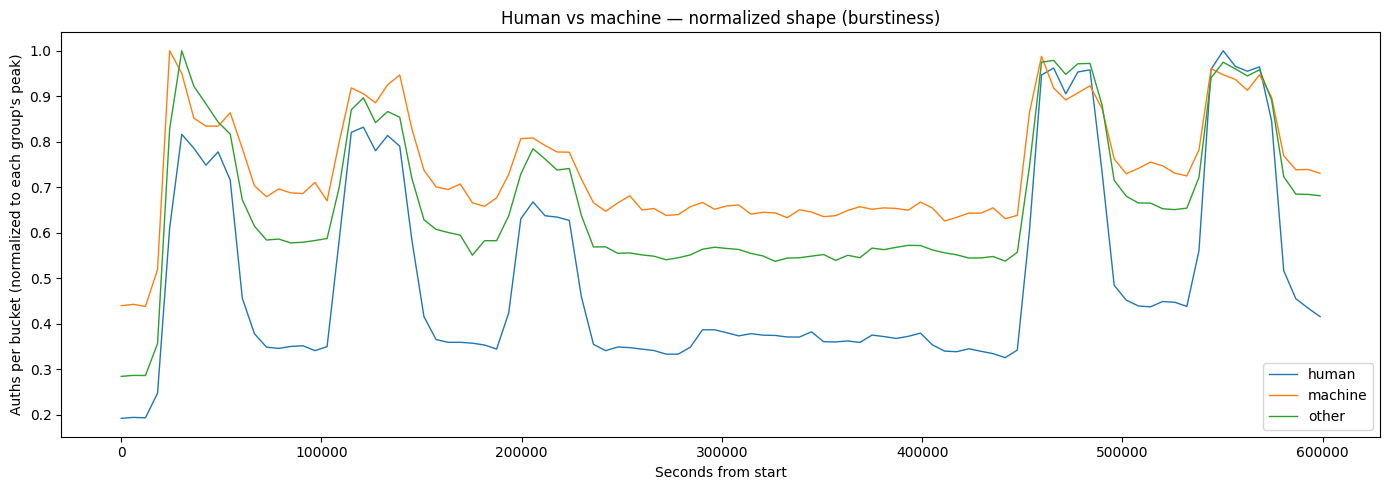

In [14]:
# --- The only thing you change: how much time to show ---
window_seconds = 604800        

bucket_seconds = max(1, window_seconds // 100)   # auto-scale resolution to the window

ts = (
    df
    .filter(pl.col("time") < window_seconds)
    .with_columns(
        bucket=(pl.col("time") // bucket_seconds).cast(pl.Int64),
        group=pl.when(pl.col("src_user").str.contains(r"\$"))
                .then(pl.lit("machine"))
                .when(pl.col("src_user").str.starts_with("U"))
                .then(pl.lit("human"))
                .otherwise(pl.lit("other")),
    )
    .group_by(["group", "bucket"])
    .agg(n_auths=pl.len())
    .collect(streaming=True)
)

fig, ax = plt.subplots(figsize=(14, 5))
for grp in ["human", "machine", "other"]:
    sub = ts.filter(pl.col("group") == grp).sort("bucket")
    counts = sub["n_auths"].to_numpy()
    ax.plot(sub["bucket"].to_numpy() * bucket_seconds,
            counts / counts.max() if counts.max() else counts,
            label=grp, linewidth=1)
ax.set_xlabel("Seconds from start")
ax.set_ylabel("Auths per bucket (normalized to each group's peak)")
ax.set_title("Human vs machine — normalized shape (burstiness)")
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_14801/3112465461.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


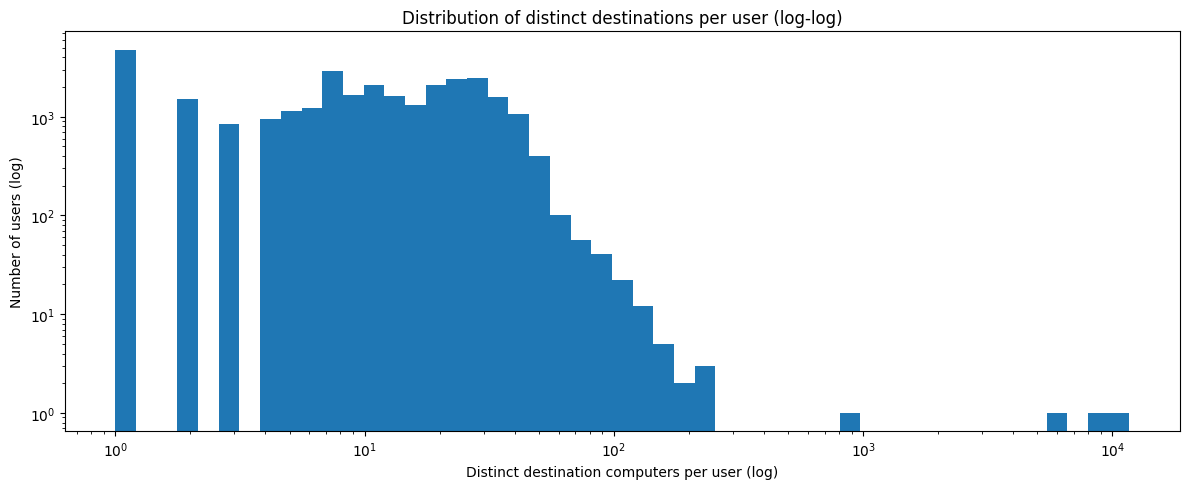

In [16]:
user_dest = (
    df
    .filter(pl.col("src_user").str.starts_with("U"))
    .group_by("src_user")
    .agg(n_distinct_dest=pl.col("dest_comp").n_unique())
    .collect(streaming=True)
)

import numpy as np

vals = user_dest["n_distinct_dest"].to_numpy()
vals_pos = vals[vals > 0]   # log bins need positive values

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(vals_pos, bins=np.logspace(0, np.log10(vals_pos.max()), 50))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distinct destination computers per user (log)")
ax.set_ylabel("Number of users (log)")
ax.set_title("Distribution of distinct destinations per user (log-log)")
plt.tight_layout()
plt.show()

## Auth type, logon type, auth orientation

In [5]:
auth_type_counts = (df.group_by("auth_type")
                      .agg(count=pl.len())
                      .sort("count", descending=True)
                      .collect(streaming=True))
print(auth_type_counts)

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_22241/3915508187.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True))


shape: (29, 2)
┌─────────────────────────────────┬───────────┐
│ auth_type                       ┆ count     │
│ ---                             ┆ ---       │
│ str                             ┆ u32       │
╞═════════════════════════════════╪═══════════╡
│ ?                               ┆ 583350819 │
│ Kerberos                        ┆ 362830725 │
│ Negotiate                       ┆ 55047638  │
│ NTLM                            ┆ 49341300  │
│ MICROSOFT_AUTHENTICATION_PACKA… ┆ 746676    │
│ …                               ┆ …         │
│ CygwinLsa                       ┆ 14        │
│ MICROSOFT_AUTHENTICATION_       ┆ 5         │
│ MICROSOFT_AUTHENTICATIO         ┆ 4         │
│ TivoliAP                        ┆ 1         │
│ N                               ┆ 1         │
└─────────────────────────────────┴───────────┘


In [6]:
auth_type_counts_users = (df.filter(pl.col("src_user").str.starts_with("U"))
                            .group_by("auth_type")
                            .agg(count=pl.len())
                            .sort("count", descending=True)
                            .collect(streaming=True))
print(auth_type_counts_users)

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_22241/1037839376.py:5: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True))


shape: (12, 2)
┌─────────────────────────────────┬───────────┐
│ auth_type                       ┆ count     │
│ ---                             ┆ ---       │
│ str                             ┆ u32       │
╞═════════════════════════════════╪═══════════╡
│ ?                               ┆ 215807156 │
│ Kerberos                        ┆ 110913007 │
│ NTLM                            ┆ 12014891  │
│ Negotiate                       ┆ 2918175   │
│ MICROSOFT_AUTHENTICATION_PACKA… ┆ 38989     │
│ …                               ┆ …         │
│ NETWARE_AUTHENTICATION_PACKAGE… ┆ 56        │
│ ACRONIS_RELOGON_AUTHENTICATION… ┆ 27        │
│ CygwinLsa                       ┆ 8         │
│ N                               ┆ 1         │
│ TivoliAP                        ┆ 1         │
└─────────────────────────────────┴───────────┘


In [ ]:
logon_type_counts = (df.group_by("logon_type")
                      .agg(count=pl.len())
                      .sort("count", descending=True)
                      .collect(streaming=True))
print(logon_type_counts)

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_22241/3095988668.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True))


shape: (10, 2)
┌───────────────────┬───────────┐
│ logon_type        ┆ count     │
│ ---               ┆ ---       │
│ str               ┆ u32       │
╞═══════════════════╪═══════════╡
│ Network           ┆ 845706092 │
│ ?                 ┆ 147250039 │
│ Service           ┆ 48894653  │
│ Unlock            ┆ 3969891   │
│ Interactive       ┆ 2052831   │
│ Batch             ┆ 1789374   │
│ NewCredentials    ┆ 1113888   │
│ NetworkCleartext  ┆ 391055    │
│ RemoteInteractive ┆ 153611    │
│ CachedInteractive ┆ 109025    │
└───────────────────┴───────────┘


In [10]:
auth_orientation = (df.group_by("auth_orientation")
                      .agg(count=pl.len())
                      .sort("count", descending=True)
                      .collect(streaming=True))
print(auth_orientation)

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_22241/149129499.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True))


shape: (7, 2)
┌──────────────────┬───────────┐
│ auth_orientation ┆ count     │
│ ---              ┆ ---       │
│ str              ┆ u32       │
╞══════════════════╪═══════════╡
│ LogOn            ┆ 468170253 │
│ LogOff           ┆ 436100783 │
│ TGS              ┆ 99003278  │
│ TGT              ┆ 38390589  │
│ AuthMap          ┆ 9571401   │
│ ScreenLock       ┆ 99556     │
│ ScreenUnlock     ┆ 94599     │
└──────────────────┴───────────┘


In [11]:
auth_orientation_counts_users = (df.filter(pl.col("src_user").str.starts_with("U"))
                            .group_by("auth_orientation")
                            .agg(count=pl.len())
                            .sort("count", descending=True)
                            .collect(streaming=True))
print(auth_orientation_counts_users)

/var/folders/m5/0wtt9ntd35j3glj9s7w_v1tw0000gn/T/ipykernel_22241/1370444448.py:5: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True))


shape: (7, 2)
┌──────────────────┬───────────┐
│ auth_orientation ┆ count     │
│ ---              ┆ ---       │
│ str              ┆ u32       │
╞══════════════════╪═══════════╡
│ LogOff           ┆ 139451528 │
│ LogOn            ┆ 125885289 │
│ TGS              ┆ 45552729  │
│ TGT              ┆ 22903992  │
│ AuthMap          ┆ 7704752   │
│ ScreenLock       ┆ 99556     │
│ ScreenUnlock     ┆ 94599     │
└──────────────────┴───────────┘
